In [3]:
from autocvd import autocvd
autocvd(num_gpus = 1, interval=1)
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '6'

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time 
from functools import partial  # Change this line - lowercase 'partial'

import jax.numpy as jnp
import jax
from jax import jit

# jax.config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec, NamedSharding         #IMPORT NEEDED FOR AUTOMATIC PARALLELISM
from jax.experimental import shard_map
from jax.scipy.special import logsumexp



import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth



from odisseo import construct_initial_state
from odisseo.dynamics import  DIRECT_ACC_MATRIX, DIRECT_ACC_LAXMAP
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL, DIFFRAX_BACKEND, TSIT5
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.utils import projection_on_GD1
from astropy import units as u
from tqdm import tqdm



from numpyro.infer import MCMC, NUTS
import numpyro
import time


code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1_000

pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)

config_sim = SimulationConfig(N_particles = N_particles,
                            return_snapshots = True, 
                            num_timesteps = 1000, 
                            external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                            acceleration_scheme = DIRECT_ACC_MATRIX,
                            softening = (0.1 * u.pc).to(code_units.code_length).value,
                            integrator = DIFFRAX_BACKEND,
                             fixed_timestep = False,
                             diffrax_solver = TSIT5,) #default values
        #the center of mass needs to be integrated backwards in time first 
config_com = config_sim._replace(N_particles=1,)


@jit
def run_simulation(params):
    params_samples = SimulationParams(t_end = 3 * u.Gyr.to(code_units.code_time),
                        Plummer_params = PlummerParams(Mtot=params['Mtot'] * u.Msun.to(code_units.code_mass),
                                                       a = params['a_Plummer'] * u.kpc.to(code_units.code_length),),
                        NFW_params = NFWParams(Mvir=params['M_NFW'] * u.Msun.to(code_units.code_mass),
                                               r_s= params['r_s'] * u.kpc.to(code_units.code_length)),
                        MN_params = MNParams(M = params['M_MN'] * u.Msun.to(code_units.code_mass),
                                             a = params['a_MN'] * u.kpc.to(code_units.code_length),
                                            b = (0.280 * u.kpc).to(code_units.code_length).value),
                        PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),  
                        G = code_units.G, )
    params_com = params_samples._replace(t_end=-params_samples.t_end,)
    mass_com = jnp.array([params_samples.Plummer_params.Mtot]) 
    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=params_com)

    states_com = final_state_com.states
    stream_coordinate_com = jax.vmap(projection_on_GD1, in_axes=(0, None))(states_com, code_units)

    return stream_coordinate_com



from functools import partial
@partial(jit, static_argnames=['coord_indices'])
def stream_likelihood(stream_coordinate_com,coord_indices=jnp.array([2, 3, 4, 5])):
    
    mask = stream_data[:, 1]>stream_coordinate_com[0, :, 1]
    n_valid = jnp.sum(mask)
    # Vectorized interpolation for all coordinates at once
    def interpolate_coord(coord_idx):
        return jnp.interp(
            stream_data[:, 1], 
            stream_coordinate_com[:20, :, 1].ravel(), 
            stream_coordinate_com[:20, :, coord_idx].ravel()
        )
    
    # Apply interpolation to all coordinates
    interp_tracks = jax.vmap(interpolate_coord)(coord_indices)  # Shape: (n_coords, n_data)
    
    # Calculate residuals for all coordinates
    data_coords = stream_data[:, coord_indices].T  # Shape: (n_coords, n_data)
    sigma = jnp.array([0.5, 10., 2., 2. ])

    residuals = jnp.where(mask[None, :], (data_coords - interp_tracks)/sigma[:, None], 0.0)
    
    total_chi2 = jnp.sum(residuals**2) 
    
    # Proper log-likelihood calculation
    n_coords = len(coord_indices)
    
    # Method 1: Full normalization (recommended)
    log_norm_term = -0.5 * n_valid * jnp.sum(jnp.log(2 * jnp.pi * sigma**2))
    log_likelihood = -0.5 * total_chi2 + log_norm_term

    
    return log_likelihood




true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
observation = jnp.array(np.load(true_GD1_observation_path)['x']).reshape(1000, 6)
true_theta = jnp.array(np.load(true_GD1_observation_path)['theta'])

# ----------------------------- Load observation & precompute target densities ----------------
true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
_obs = np.load(true_GD1_observation_path)
observation = jnp.array(_obs['x']).reshape(1000, 6)  # will be used only to compute target densities
true_theta = jnp.array(_obs['theta'])

# Precompute the target densities ONCE (expensive step)
stream_data = observation[:, [1, 2]]  # phi1, phi2

@jit
def evaluate_loglikelihood(theta_1, ):

        # print(f"In the corrector: theta_1 shape: {theta_1.shape}, target shape: {target.shape}")
        output = run_simulation(theta_1)

        # return stream_likelihood(model_stream=output, obs_stream=observation, obs_errors=jnp.array([0.25, 0.001, 0.15, 5., 0.1, 0.0001]))
        return stream_likelihood(stream_coordinate_com=output, )


# True parameter values (without code_units transformation)
true_params = jnp.array([
    # 3.0,                    # t_end (Gyr)
    10**4.05,              # Plummer Mtot (Msun) 
    8.0 * 1e-3,            # Plummer a (kpc) - converted from pc to kpc
    4.3683325e11,          # NFW Mvir (Msun)
    16.0,                  # NFW r_s (kpc)
    68_193_902_782.346756, # MN M (Msun)
    3.0,                   # MN a (kpc)
])

# Prior bounds for each parameter
prior_bounds = jnp.array([
    # [0.5, 5.0],                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],              # Plummer Mtot: 10^3 to 10^4.5 Msun
    [8.0 * 1e-3 * 0.5, 8.0 * 1e-3 * 2.0],  # Plummer a: 1/4 to 2x true (kpc)
    [4.3683325e11 * 0.5, 4.3683325e11 * 2.0],  # NFW Mvir: 1/4 to 2x true
    [16.0 * 0.5, 16.0 * 2.0],    # NFW r_s: 1/4 to 2x true (kpc)
    [68_193_902_782.346756 * 0.5, 68_193_902_782.346756 * 2.0],  # MN M: 1/4 to 2x true
    [3.0 * 0.5, 3.0 * 2.0],      # MN a: 1/4 to 2x true (kpc)
])  # Shape: (7, 2) for [min, max] bounds

def draw_from_prior(key):
    """Draw samples from uniform prior."""
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey, shape=(7,))
    
    # Transform uniform [0,1] to [min, max] for each parameter
    samples = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])
    samples = { 'Mtot': samples[0], 'a_Plummer': samples[1], 'M_NFW': samples[2], 'r_s': samples[3], 'M_MN': samples[4], 'a_MN': samples[5]}
    return samples

param_order = ['Mtot', 'a_Plummer', 'M_NFW', 'r_s', 'M_MN', 'a_MN']
@jit
def dict_to_array(theta_dict):
    return jnp.array([theta_dict[k] for k in param_order])

@jit
def array_to_dict(theta_array):
    return {k: theta_array[i] for i, k in enumerate(param_order)}

@jit
def evaluate_log_prior(theta):
    uniform = numpyro.distributions.Uniform(prior_bounds[:, 0], prior_bounds[:, 1])
    log_prior= uniform.log_prob(dict_to_array(theta)).sum()
    return log_prior


@jit
def evaluate_log_posterior_grad(theta):
    """Compute gradient of log posterior."""
    
    def log_posterior(theta):
        log_prior = evaluate_log_prior(theta)
        log_like = evaluate_loglikelihood(theta)
        return log_prior + log_like
    
    # Get both value and gradient
    log_post_val, grad = jax.value_and_grad(log_posterior)(theta)
    return log_post_val, grad

@jit
def evaluate_log_posterior(theta):
    log_prior = evaluate_log_prior(theta)
    log_like = evaluate_loglikelihood(theta_1 = theta, )
    return log_prior + log_like
    # return log_like


# potential function for NUTS (NumPyro expects potential = -log_prob)
@jit
def potential_fn(theta):
    return -evaluate_log_posterior(theta)



In [4]:
posterior_SBI = np.load('../logs/OdisseoCrossAttentionSetTransformer_small_AllParameters_Position_uniforprior_2e5_TSIT5/pictures/predicted_theta_test_set.npz')['predicted_theta'][0]
init_positions = np.mean(posterior_SBI, axis=0)
init_positions = init_positions[1:]
init_positions = array_to_dict(init_positions)
init_positions['M_NFW'] = 10**init_positions['M_NFW']
init_positions['M_MN'] = 10**init_positions['M_MN']
init_positions['Mtot'] = 10**init_positions['Mtot']

theta_test = init_positions
lp = evaluate_loglikelihood(theta_test)
print(lp)

-79185.39


In [5]:
evaluate_log_prior(init_positions)

Array(-63.14815, dtype=float32)

In [ ]:
# ---------------- NUTS / MCMC RUN ----------------
# Tuning parameters
num_chains = 1
num_warmup = 10
num_samples = 100
target_accept = 0.8  # typical NUTS tuning: 0.8..0.9

# Prepare initial positions (one per chain)
master_key = jax.random.PRNGKey(0)
# init_keys = jax.random.split(master_key, num_chains)
# init_positions = jax.vmap(draw_from_prior)(init_keys)  # shape (num_chains, D)

posterior_SBI = np.load('../logs/OdisseoCrossAttentionSetTransformer_small_AllParameters_Position_uniforprior_2e5_TSIT5/pictures/predicted_theta_test_set.npz')['predicted_theta'][0]
init_positions = np.mean(posterior_SBI, axis=0)
init_positions = init_positions[1:]
init_positions = array_to_dict(init_positions)
init_positions['M_NFW'] = 10**init_positions['M_NFW']
init_positions['M_MN'] = 10**init_positions['M_MN']
init_positions['Mtot'] = 10**init_positions['Mtot']

# Build NUTS kernel with potential_fn
kernel = NUTS(potential_fn=potential_fn, target_accept_prob=target_accept, max_tree_depth=3)

mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains, progress_bar=True )
start_time = time.time()

# Run MCMC. For potential_fn, pass init_params as initial positions (num_chains, D).
mcmc.run(master_key, init_params=init_positions)


sample:  29%|██▉       | 32/110 [05:14<16:10, 12.44s/it, 7 steps of size 1.62e-03. acc. prob=0.81]

In [5]:
# ---------------- EXTRACT & POSTPROCESS ----------------
samples = mcmc.get_samples(group_by_chain=True)

In [6]:
samples

{'M_MN': Array([[8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854e+10, 8.028854e+10, 8.028854e+10, 8.028854e+10,
         8.028854

In [7]:
mcmc.get_extra_fields()

{'diverging': Array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True], dtype=bool)}

In [9]:
df = pd.DataFrame(sample_dictonary)

NameError: name 'sample_dictonary' is not defined

In [22]:
pd.DataFrame(sample_dictonary)

,M_MN,M_NFW,Mtot,a_MN,a_Plummer,r_s,t_end
0,8.028854e+10,5.314145e+11,17032.931641,3.612324,0.009031,20.555031,2.910893
1,8.028854e+10,5.314145e+11,17032.931641,3.612603,0.008893,20.554867,2.910883
2,8.028854e+10,5.314145e+11,17032.931641,3.612761,0.008857,20.554781,2.910863
3,8.028854e+10,5.314145e+11,17032.931641,3.612808,0.008757,20.554827,2.910965
4,8.028854e+10,5.314145e+11,17032.931641,3.612779,0.008735,20.554825,2.910900
...,...,...,...,...,...,...,...
995,8.028854e+10,5.314145e+11,17032.931641,3.623312,0.006607,20.552425,2.911309
996,8.028854e+10,5.314145e+11,17032.931641,3.623322,0.006414,20.552401,2.911311
997,8.028854e+10,5.314145e+11,17032.931641,3.623267,0.006312,20.552206,2.911189
998,8.028854e+10,5.314145e+11,17032.931641,3.623323,0.006007,20.552307,2.911417


In [8]:
df

NameError: name 'df' is not defined

/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/chainconsumer/plotter.py:861: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(base.extents[p2])
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/chainconsumer/plotter.py:860: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(base.extents[p1])
/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


IndexError: index 0 is out of bounds for axis 0 with size 0

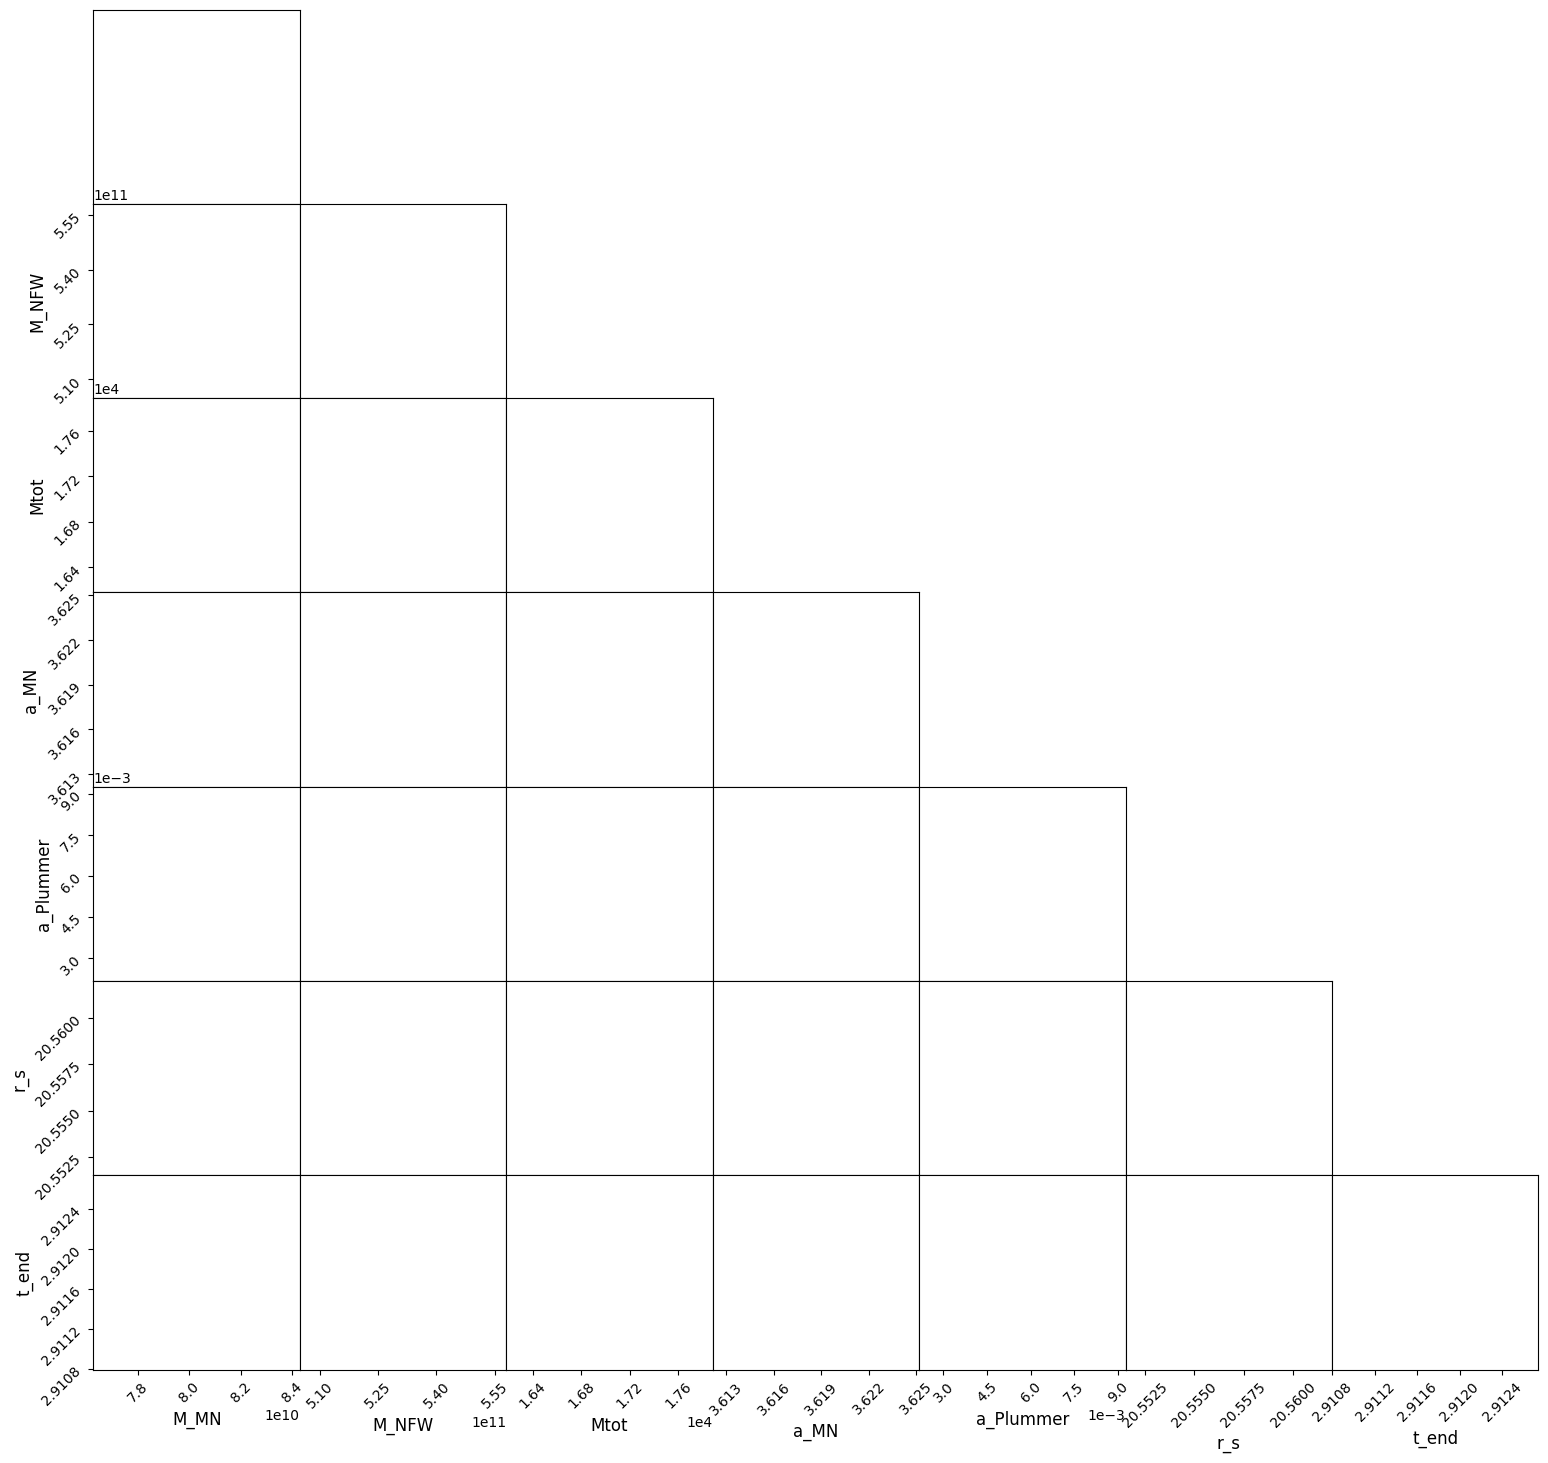

In [26]:
sample_dictonary = {k: v[0] for k, v in samples.items()}
# chain_np = np.array(samples)
# df = pd.DataFrame(sample_dictonary, columns=['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$'])
df = pd.DataFrame(sample_dictonary)
df = df.astype(float)
# Convert to float and handle any non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.empty:
    # If no numeric columns, convert all to float
    numeric_df = df.astype(float)
# Create corner plot with ChainConsumer
c = ChainConsumer()
c.add_chain(Chain(samples=df, name="Experimental Results", ), )
# c.add_truth(Truth(location={
#         '$t_{end}$': true_theta[0] * code_units.code_time.to(u.Gyr),
#         '$M_{plummer}$': true_theta[1] * code_units.code_mass.to(u.Msun),
#         '$a_{plummer}$': true_theta[2] * code_units.code_length.to(u.kpc),
#         '$M_{NFW}$': true_theta[3] * code_units.code_mass.to(u.Msun),
#         '$r_{NFW}$': true_theta[4] * code_units.code_length.to(u.kpc),
#         '$M_{MN}$': true_theta[5] * code_units.code_mass.to(u.Msun),
#         '$a_{MN}$': true_theta[6] * code_units.code_length.to(u.kpc),
# }))
fig = c.plotter.plot()   

In [ ]:

# Create multi-index DataFrame
# First, reshape the array to (num_chains * num_steps, theta_dim)
chains_reshaped = chain_np
chains_np = chain_np

# Create multi-index
chain_indices = np.repeat(range(num_chains), chains_np.shape[1])  # [0,0,0,...,1,1,1,...,2,2,2,...]
draw_indices = np.tile(range(chains_np.shape[1]), num_chains)     # [0,1,2,...,0,1,2,...,0,1,2,...]

# Create DataFrame with multi-index
df_multiple_chains = pd.DataFrame(
    chains_reshaped, 
    columns=param_names,
    index=pd.MultiIndex.from_arrays(
        [chain_indices, draw_indices], 
        names=['chain', 'draw']
    )
)

# Convert to xarray Dataset
xdata_multiple_chains = xr.Dataset.from_dataframe(df_multiple_chains)

# Create InferenceData object
idata = az.InferenceData(posterior=xdata_multiple_chains)
# Now you can use all ArviZ diagnostic functions:

# 1. Summary statistics
print(az.summary(idata))

# 2. Trace plots
az.plot_trace(idata)

# 3. R-hat convergence diagnostic
rhat = az.rhat(idata)
print(f"R-hat values:\n{rhat}")

# 4. Effective sample size
ess = az.ess(idata)
print(f"Effective sample size:\n{ess}")

# 5. Autocorrelation plots
az.plot_autocorr(idata, max_lag=10)

# 6. Rank plots (for convergence diagnostics)
az.plot_rank(idata)

# 7. Energy plots (if you have energy/log probability)
# az.plot_energy(idata)

# 8. Posterior plots
az.plot_posterior(idata)

# 9. Corner plot (pair plot)
az.plot_pair(idata, kind='scatter')

# 10. Forest plot
az.plot_forest(idata)

ValueError: Shape of passed values is (200, 7), indices imply (14, 7)

In [ ]:
import arviz as az
import xarray as xr

num_chains = 6

thin = 1
all_chains_post_thinned = all_chains_post[:, ::thin]

# Convert JAX array to numpy if needed
chains_np = np.array(all_chains_post)  # Shape: (num_chains, num_steps, theta_dim)

# Define parameter names
param_names = ['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$']

# Create multi-index DataFrame
# First, reshape the array to (num_chains * num_steps, theta_dim)
chains_reshaped = chains_np.reshape(-1, chains_np.shape[-1])

# Create multi-index
chain_indices = np.repeat(range(num_chains), chains_np.shape[1])  # [0,0,0,...,1,1,1,...,2,2,2,...]
draw_indices = np.tile(range(chains_np.shape[1]), num_chains)     # [0,1,2,...,0,1,2,...,0,1,2,...]

# Create DataFrame with multi-index
df_multiple_chains = pd.DataFrame(
    chains_reshaped, 
    columns=param_names,
    index=pd.MultiIndex.from_arrays(
        [chain_indices, draw_indices], 
        names=['chain', 'draw']
    )
)

# Convert to xarray Dataset
xdata_multiple_chains = xr.Dataset.from_dataframe(df_multiple_chains)

# Create InferenceData object
idata = az.InferenceData(posterior=xdata_multiple_chains)



In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from jax import jit
from numpyro.infer import MCMC, AIES
import numpyro

numpyro.set_host_device_count(1)

# ---------- PARAMETER DEFINITIONS ----------
param_names = ("t_end","Mtot","a_Plummer","M_NFW","r_s","M_MN","a_MN")

# Linear-space prior bounds
prior_bounds_linear = jnp.array([
    [0.5, 5.0],                    # t_end (time in Gyr) – can stay linear
    [10**3, 10**4.5],              # Plummer Mtot
    [8.0e-3 * 0.25, 8.0e-3 * 2.0], # Plummer a (kpc)
    [4.3683325e11 * 0.25, 4.3683325e11 * 2.0],  # NFW Mvir
    [16.0 * 0.25, 16.0 * 2.0],     # NFW r_s (kpc)
    [6.8193902782346756e10 * 0.25, 6.8193902782346756e10 * 2.0],  # MN M
    [3.0 * 0.25, 3.0 * 2.0],       # MN a (kpc)
])

# Which parameters to log-transform? (everything except t_end)
log_mask = jnp.array([False, True, True, True, True, True, True])

# Bounds in log-space
prior_bounds_log = jnp.where(
    log_mask[:, None],
    jnp.log(prior_bounds_linear),
    prior_bounds_linear
)

# ---------- UTILITIES ----------
def pack_theta(theta_dict):
    return jnp.array([theta_dict[k] for k in param_names])

def unpack_theta(theta_vec):
    return {k: theta_vec[i] for i,k in enumerate(param_names)}

def exp_transform(theta_log):
    """Convert log-space vector to linear-space where needed"""
    return jnp.where(log_mask, jnp.exp(theta_log), theta_log)

# ---------- PRIORS ----------
@jit
def evaluate_log_prior_vec(theta_log):
    """Flat priors in log-space (log-uniform in linear space)"""
    in_bounds = jnp.all((theta_log >= prior_bounds_log[:, 0]) &
                        (theta_log <= prior_bounds_log[:, 1]))
    log_volume = jnp.sum(prior_bounds_log[:, 1] - prior_bounds_log[:, 0])
    log_density = -log_volume
    return jnp.where(in_bounds, log_density, -jnp.inf)

# ---------- LIKELIHOOD ----------
@jit
def stream_likelihood(model_stream, obs_stream, obs_errors):
    def obs_log_prob(obs):
        def model_log_prob(model_point):
            return log_diag_multivariate_normal(obs, model_point, obs_errors)
        log_probs = jax.vmap(model_log_prob)(model_stream)
        log_p_stream = jax.scipy.special.logsumexp(log_probs) - jnp.log(model_stream.shape[0])
        return log_p_stream
    logL_values = jax.vmap(obs_log_prob)(obs_stream)
    return jnp.sum(logL_values)

@jit
def evaluate_loglikelihood(observation, theta_log):
    theta_lin = unpack_theta(exp_transform(theta_log))
    key = jax.random.PRNGKey(0)
    model_stream = run_simulation(key, theta_lin)
    return stream_likelihood(
        model_stream=model_stream,
        obs_stream=observation,
        obs_errors=jnp.array([0.25, 0.001, 0.15, 5.0, 0.1, 1e-4])
    )

@jit
def log_posterior_vec(theta_log):
    lp = evaluate_log_prior_vec(theta_log)
    ll = jax.lax.cond(lp > -jnp.inf,
                      lambda _: evaluate_loglikelihood(observation, theta_log),
                      lambda _: -jnp.inf,
                      operand=None)
    return lp + ll

def potential_fn(theta_log):
    return -log_posterior_vec(theta_log)

# ---------- INITIALIZATION ----------
def draw_from_prior(key):
    u = jax.random.uniform(key, shape=(7,))
    return prior_bounds_log[:, 0] + u * (prior_bounds_log[:, 1] - prior_bounds_log[:, 0])

num_walkers = 40
num_warmup  = 100
num_samples = 1000

master_key = jax.random.PRNGKey(42)
walker_keys = jax.random.split(master_key, num_walkers)
init_positions = jax.vmap(draw_from_prior)(walker_keys)

kernel = AIES(potential_fn=potential_fn,
              moves={AIES.StretchMove() : 1.2})

mcmc = MCMC(kernel, num_warmup=num_warmup,
            num_samples=num_samples, num_chains=num_walkers,
            chain_method='vectorized')

mcmc.run(master_key, init_params=init_positions)
samples = mcmc.get_samples(group_by_chain=True)

if isinstance(samples, dict):
    key0 = next(iter(samples.keys()))
    samples = samples[key0]

samples = jnp.reshape(samples, (-1, samples.shape[-1]))

# Convert back to linear space for interpretation
samples_lin = exp_transform(samples)

samples_df = pd.DataFrame(np.array(samples_lin), columns=list(param_names))
print(samples_df.describe(percentiles=[0.16, 0.5, 0.84]))


warmup:   2%|▏         | 27/1100 [09:46<6:18:23, 21.16s/it, acc. prob=0.11]

In [ ]:
# --- NEW: imports for NumPyro AIES ---
from numpyro.infer import MCMC, AIES
import numpyro
numpyro.set_host_device_count(1)  # or >1 if you know what you're doing

# ------------ SMALL FIXES / HELPERS ------------

# Convert between vector (AIES expects a 1D array) and your dict format
param_names = ("t_end","Mtot","a_Plummer","M_NFW","r_s","M_MN","a_MN")

def pack_theta(theta_dict):
    return jnp.array([theta_dict[k] for k in param_names])

def unpack_theta(theta_vec):
    return {k: theta_vec[i] for i,k in enumerate(param_names)}

# Prior bounds as arrays (kept from your code)
prior_bounds = jnp.array([
    [0.5, 5.0],                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],              # Plummer Mtot
    [8.0e-3 * 0.25, 8.0e-3 * 2.0], # Plummer a (kpc)
    [4.3683325e11 * 0.25, 4.3683325e11 * 2.0],  # NFW Mvir
    [16.0 * 0.25, 16.0 * 2.0],     # NFW r_s (kpc)
    [6.8193902782346756e10 * 0.25, 6.8193902782346756e10 * 2.0],  # MN M
    [3.0 * 0.25, 3.0 * 2.0],       # MN a (kpc)
])

# --- FIX: uniform log-prior with bounds check (return -inf out of bounds) ---
@jit
def evaluate_log_prior_vec(theta_vec):
    in_bounds = jnp.all((theta_vec >= prior_bounds[:, 0]) & (theta_vec <= prior_bounds[:, 1]))
    log_volume = jnp.sum(jnp.log(prior_bounds[:, 1] - prior_bounds[:, 0]))
    log_density = -log_volume
    return jnp.where(in_bounds, log_density, -jnp.inf)

# --- FIX: better broadcasting in stream_likelihood ---
@jit
def stream_likelihood(model_stream, obs_stream, obs_errors):
    """
    model_stream: (N_model, D)
    obs_stream:   (N_obs, D)
    obs_errors:   (D,)
    """
    def obs_log_prob(obs):
        # vectorize over all model points
        def model_log_prob(model_point):
            return log_diag_multivariate_normal(obs, model_point, obs_errors)
        log_probs = jax.vmap(model_log_prob)(model_stream)
        log_p_stream = jax.scipy.special.logsumexp(log_probs) - jnp.log(model_stream.shape[0])
        return log_p_stream

    # vmap over observations, errors shared (in_axes=(0, None))
    logL_values = jax.vmap(obs_log_prob, in_axes=(0,))(obs_stream)
    # If you truly want a pure-stream model, keep as is; otherwise add background mixture here
    return jnp.sum(logL_values)

# --- FIX: squeeze observation to (N_obs, 6) once ---
true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
_observation_loaded = np.load(true_GD1_observation_path)
observation = jnp.array(_observation_loaded['x'][:1000]).reshape(-1, 6)   # (1000, 6)
true_theta = jnp.array(_observation_loaded['theta'][:1000])  # (1000, ?), unused below

# Keep your run_simulation() as-is; it expects a dict of params.

@jit
def evaluate_loglikelihood(observation, theta_dict):
    key = jax.random.PRNGKey(0)  # deterministic simulator; change if you want RNG marginalization
    model_stream = run_simulation(key, theta_dict)  # expect (N_model, 6)
    return stream_likelihood(model_stream=model_stream,
                             obs_stream=observation,
                             obs_errors=jnp.array([0.25, 0.001, 0.15, 5.0, 0.1, 1e-4]))

# Scalar log-posterior on a parameter vector (what AIES needs)
@jit
def log_posterior_vec(theta_vec):
    lp = evaluate_log_prior_vec(theta_vec)
    # short-circuit if out of bounds
    def in_support(lp_):
        return lp_ > -jnp.inf
    ll = jax.lax.cond(in_support(lp),
                      lambda _: evaluate_loglikelihood(observation, unpack_theta(theta_vec)),
                      lambda _: -jnp.inf,
                      operand=None)
    return lp + ll

# NumPyro AIES uses potential energy = -log_prob
def potential_fn(theta_vec):
    return -log_posterior_vec(theta_vec)

# ------------- PRIORS & INIT ENSEMBLE -------------
def draw_from_prior(key):
    u = jax.random.uniform(key, shape=(7,))
    samples = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])
    return samples  # vector (7,)

# ------------- RUN AIES -------------
# You generally want >= 2*dim walkers. Here dim=7 → pick 32 walkers.
num_walkers = 1000
num_warmup  = 10   # tune to taste
num_samples = 1_000  # tune to taste

master_key = jax.random.PRNGKey(42)
walker_keys = jax.random.split(master_key, num_walkers)
init_positions = jax.vmap(draw_from_prior)(walker_keys)  # (num_walkers, 7)

# Build kernel & MCMC driver
# kernel = AIES(potential_fn=potential_fn,
#               moves={AIES.DEMove() : 0.5,
#                      AIES.StretchMove() : 0.5}) # no model, we use potential_fn
kernel = AIES(potential_fn=potential_fn,
              moves={AIES.StretchMove() : 0.5}) # no model, we use potential_fn
mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_walkers, chain_method='vectorized')

# IMPORTANT: pass init_params = ensemble (num_walkers, dim)
mcmc.run(master_key, init_params=init_positions)
mcmc.print_summary(exclude_deterministic=False)


# fallback if your version stores a different key (rare)
samples = mcmc.get_samples(group_by_chain=True)
# If it’s already an array, leave it; otherwise try the only array-like entry.
if isinstance(samples, dict):
    key0 = next(iter(samples.keys()))
    samples = samples[key0]

# For convenience: merge chains & walkers into one sample axis
samples = jnp.reshape(samples, (-1, samples.shape[-1]))  # (num_samples*num_walkers, 7)

# Convert to a pandas DataFrame with names
samples_df = pd.DataFrame(np.array(samples), columns=list(param_names))
print(samples_df.describe(percentiles=[0.16, 0.5, 0.84]))


/export/home/vgiusepp/miniconda3/envs/sbi_sim/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
warmup:   1%|          | 6/1010 [02:17<5:51:23, 21.00s/it, acc. prob=0.22]

In [ ]:
import numpy as np
a = np.load('./mcmc_numpyro_samples.npz')

In [ ]:
a['raw'].shape

(5, 50, 7)

In [ ]:
from autocvd import autocvd
autocvd(num_gpus = 1, interval=1)
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '6'

import numpy as np
import matplotlib.pyplot as plt
import time 
from functools import partial  # Change this line - lowercase 'partial'

import jax.numpy as jnp
import jax
from jax import jit

# jax.config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec, NamedSharding         #IMPORT NEEDED FOR AUTOMATIC PARALLELISM
from jax.experimental import shard_map



import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth



from odisseo import construct_initial_state
from odisseo.dynamics import  DIRECT_ACC_MATRIX, DIRECT_ACC_LAXMAP
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.utils import projection_on_GD1
from astropy import units as u
import blackjax
from tqdm import tqdm


code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1000


config_sim = SimulationConfig(N_particles = N_particles,
                            return_snapshots = False, 
                            num_timesteps = 1000, 
                            external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                            acceleration_scheme = DIRECT_ACC_MATRIX,
                            softening = (0.1 * u.pc).to(code_units.code_length).value,) #default values
        #the center of mass needs to be integrated backwards in time first 
config_com = config_sim._replace(N_particles=1,)

@jit
def run_simulation(rng_key, params):
    params_samples = SimulationParams(t_end = params['t_end'] * u.Gyr.to(code_units.code_time),
                        Plummer_params = PlummerParams(Mtot=params['Mtot'] * u.Msun.to(code_units.code_mass),
                                                       a = params['a_Plummer'] * u.kpc.to(code_units.code_length),),
                        NFW_params = NFWParams(Mvir=params['M_NFW'] * u.Msun.to(code_units.code_mass),
                                               r_s= params['r_s'] * u.kpc.to(code_units.code_length)),
                        MN_params = MNParams(M = params['M_MN'] * u.Msun.to(code_units.code_mass),
                                             a = params['a_MN'] * u.kpc.to(code_units.code_length),
                                            b = (0.280 * u.kpc).to(code_units.code_length).value),
                        PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),  
                        G = code_units.G, )

    params_com = params_samples._replace(t_end=-params_samples.t_end,)
    mass_com = jnp.array([params_samples.Plummer_params.Mtot]) 

    pos_com_final = jnp.array([[params['x'], params['y'], params['z']]]) * u.kpc.to(code_units.code_length)
    vel_com_final = jnp.array([[params['vx'], -params['vy'], -params['vz']]]) * (u.km/u.s).to(code_units.code_velocity)

    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=params_com)
    #we calculate the final position and velocity of the center of mass
    pos_com = final_state_com[:, 0]
    vel_com = final_state_com[:, 1]

    #we construct the initial state of the Plummer sphere
    positions, velocities, mass = Plummer_sphere(key=rng_key, params=params_samples, config=config_sim)
    #we add the center of mass position and velocity to the Plummer sphere particles
    positions = positions + pos_com
    velocities = velocities + vel_com
    #initialize the initial state
    initial_state_stream = construct_initial_state(positions, velocities, )
    #run the simulation
    final_state = time_integration(initial_state_stream, mass, config=config_sim, params=params_samples)

    #projection on the GD1 stream
    stream = projection_on_GD1(final_state, code_units=code_units,)

    return stream

def log_diag_multivariate_normal(x, mean, sigma):
        """
        Log PDF of a multivariate Gaussian with diagonal covariance.
        
        Parameters
        ----------
        x : (D,)
        mean : (D,)
        sigma : (D,)  # standard deviations for each dimension
        """
        diff = (x - mean) / sigma
        D = x.shape[0]
        log_det = 2.0 * jnp.sum(jnp.log(sigma))
        norm_const = -0.5 * (D * jnp.log(2 * jnp.pi) + log_det)
        exponent = -0.5 * jnp.sum(diff**2)
        return norm_const + exponent

@jit
def stream_likelihood(model_stream, obs_stream, obs_errors, ):
    """
    Log-likelihood of observed stars given simulated stream (diagonal covariance).
    
    Parameters
    ----------
    model_stream : (N_model, D)
    obs_stream : (N_obs, D)
    obs_errors : (N_obs, D)   # per-dimension standard deviations
    tau : float
        Stream membership fraction
    p_field : float
        Background probability density
    """
    def obs_log_prob(obs, sigma):
        def model_log_prob(model_point):
            return log_diag_multivariate_normal(obs, model_point, sigma)

        # Compute log_probs for all model points
        log_probs = jax.vmap(model_log_prob)(model_stream)
        
        # Numerically stable average: log(mean(exp(log_probs)))
        log_p_stream = jax.scipy.special.logsumexp(log_probs) - jnp.log(model_stream.shape[0])
        
        return log_p_stream

    # Vectorize over observations
    logL_values = jax.vmap(obs_log_prob)(obs_stream, jnp.repeat(obs_errors, obs_stream.shape[0]).reshape(-1, 6))
    return jnp.sum(logL_values)


true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
observation = jnp.array(np.load(true_GD1_observation_path)['x'][:1000]).reshape(1000, 6)
true_theta = jnp.array(np.load(true_GD1_observation_path)['theta'][:1000])

@jit
def evaluate_loglikelihood(observation, theta_1, ):

        key = jax.random.PRNGKey(0)
        # print(f"In the corrector: theta_1 shape: {theta_1.shape}, target shape: {target.shape}")
        output = run_simulation(key, theta_1)

        return stream_likelihood(model_stream=output, obs_stream=observation, obs_errors=jnp.array([0.25, 0.001, 0.15, 5., 0.1, 0.0001]))


# True parameter values (without code_units transformation)
true_params = jnp.array([
    3.0,                    # t_end (Gyr)
    10**4.05,              # Plummer Mtot (Msun) 
    8.0 * 1e-3,            # Plummer a (kpc) - converted from pc to kpc
    4.3683325e11,          # NFW Mvir (Msun)
    16.0,                  # NFW r_s (kpc)
    68_193_902_782.346756, # MN M (Msun)
    3.0,                   # MN a (kpc)
])

# Prior bounds for each parameter
prior_bounds = jnp.array([
    [0.5, 5.0],                                                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],                                             # Plummer Mtot: 10^3 to 10^4.5 Msun
    [1/4 * 0.008, 2 * 0.008],                                    # Plummer a: 1/4 to 2x true (kpc)
    [1/4 * 4.3683325e11, 2 * 4.3683325e11],  # NFW Mvir: 1/4 to 2x true
    [1/4 * 16.0, 2 * 16.0],                                      # NFW r_s: 1/4 to 2x true (kpc)
    [1/4 * 68_193_902_782.346756, 2 * 68_193_902_782.346756],  # MN M: 1/4 to 2x true
    [1/4 * 3.0, 2 * 3.0],                                        # MN a: 1/4 to 2x true (kpc)
    [10.0, 14.0],                                                 # x position (kpc)
    [0.1, 2.5],                                                   # y position (kpc)
    [6.0, 8.0],                                                   # z position (kpc)
    [90.0, 115.0],                                                # vx velocity (km/s)
    [230.0, 280.0],                                             # vy velocity (km/s)
    [80.0, 120.0]                                               # vz velocity (km/s)
])  # Shape: (13, 2) for [min, max] bounds

def draw_from_prior(key):
    """Draw samples from uniform prior."""
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey, shape=(13,))  # Changed from 7 to 13
    
    # Transform uniform [0,1] to [min, max] for each parameter
    samples = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])
    samples = {
        't_end': samples[0], 'Mtot': samples[1], 'a_Plummer': samples[2], 
        'M_NFW': samples[3], 'r_s': samples[4], 'M_MN': samples[5], 'a_MN': samples[6],
        'x': samples[7], 'y': samples[8], 'z': samples[9],
        'vx': samples[10], 'vy': samples[11], 'vz': samples[12]
    }
    return samples

@jit
def evaluate_log_prior(theta):
    """Evaluate log prior density (uniform)."""
    # Check if all parameters are within bounds
    in_bounds = jnp.all((theta >= prior_bounds[:, 0]) & (theta <= prior_bounds[:, 1]))
    
    # For uniform distribution: log(density) = -log(volume)
    # Volume = product of interval widths
    log_volume = jnp.sum(jnp.log(prior_bounds[:, 1] - prior_bounds[:, 0]))
    
    # Return -inf if out of bounds, -log_volume if in bounds
    return jnp.where(in_bounds, -log_volume, -jnp.inf)
    # return log_volume


def draw_from_proposal(key, theta, sigma2_prop):
    key, sk = jax.random.split(key)
    theta_prime = jax.random.normal(sk, shape=theta.shape) * jnp.sqrt(sigma2_prop) + theta
    return theta_prime, key

@jit
def evaluate_log_posterior_grad(observation, theta):
    """Compute gradient of log posterior."""
    
    def log_posterior(theta):
        log_prior = evaluate_log_prior(theta)
        log_like = evaluate_loglikelihood(observation, theta)
        return log_prior + log_like
    
    # Get both value and gradient
    log_post_val, grad = jax.value_and_grad(log_posterior)(theta)
    return log_post_val, grad

@jit
def evaluate_log_posterior(theta):
    log_prior = evaluate_log_prior(theta)
    log_like = evaluate_loglikelihood(theta_1 = theta, observation=observation,)
    return log_prior + log_like


import jax
import jax.numpy as jnp
from jax import jit
import numpy as np
import pandas as pd
from numpyro.infer import MCMC, NUTS
import numpyro
import time

numpyro.set_host_device_count(1)  # set to number of local devices if you want to run chains vectorized

# ---------------- PARAMETERS / TRANSFORMS ----------------
param_names = ("t_end", "Mtot", "a_Plummer", "M_NFW", "r_s", "M_MN", "a_MN", 
               "x", "y", "z", "vx", "vy", "vz")
D = len(param_names)  # Now D = 13


# Prior bounds for each parameter
prior_bounds_linear = jnp.array([
    [0.5, 5.0],                                                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],                                             # Plummer Mtot: 10^3 to 10^4.5 Msun
    [1/4 * 0.008, 2 * 0.008],                                    # Plummer a: 1/4 to 2x true (kpc)
    [1/4 * 4.3683325e11, 2 * 4.3683325e11],  # NFW Mvir: 1/4 to 2x true
    [1/4 * 16.0, 2 * 16.0],                                      # NFW r_s: 1/4 to 2x true (kpc)
    [1/4 * 68_193_902_782.346756, 2 * 68_193_902_782.346756],  # MN M: 1/4 to 2x true
    [1/4 * 3.0, 2 * 3.0],                                        # MN a: 1/4 to 2x true (kpc)
    [10.0, 14.0],                                                 # x position (kpc)
    [0.1, 2.5],                                                   # y position (kpc)
    [6.0, 8.0],                                                   # z position (kpc)
    [90.0, 115.0],                                                # vx velocity (km/s)
    [230.0, 280.0],                                             # vy velocity (km/s)
    [80.0, 120.0]                                                # vz velocity (km/s)
])  # Shape: (13, 2) for [min, max] bounds

# Choose which parameters we sample in log-space.
# Here: everything except t_end (index 0) is log-transformed
log_mask = jnp.array([False, True, True, True, False, True, False,  # original 7 params
                      True, True, True, True, True, True])    # 6 position/velocity params (linear space)

# Bounds in transformed space:
prior_bounds_trans = jnp.where(log_mask[:, None],
                               jnp.log(prior_bounds_linear),
                               prior_bounds_linear)  # shape (D,2)

# helper: convert theta_log (sampled) -> theta_lin for simulator (dict expected by run_simulation)
@jit
def theta_log_to_dict(theta_log):
    # theta_lin: exp for log_mask entries, identity otherwise
    theta_lin = jnp.where(log_mask, jnp.exp(theta_log), theta_log)
    # build dict in the order of param_names
    return {k: theta_lin[i] for i, k in enumerate(param_names)}

# ---------------- PRIORS & POSTERIOR ----------------
@jit
def log_prior_trans(theta_log):
    """Flat prior in transformed space: uniform in theta_log bounds.
       This corresponds to log-uniform (Jeffreys-like) prior on original parameters for log_mask=True entries.
    """
    in_bounds = jnp.all((theta_log >= prior_bounds_trans[:, 0]) & (theta_log <= prior_bounds_trans[:, 1]))
    # uniform density in transformed space: -log(volume)
    log_vol = jnp.sum(prior_bounds_trans[:, 1] - prior_bounds_trans[:, 0])
    log_density = -log_vol
    return jnp.where(in_bounds, log_density, -jnp.inf)

# Wrap your existing likelihood call:
# evaluate_loglikelihood(observation, theta_dict)  # <- already present in your code
# We will call it with theta_dict = theta_log_to_dict(theta_log)

@jit
def log_likelihood_trans(theta_log):
    theta_dict = theta_log_to_dict(theta_log)
    # You already defined evaluate_loglikelihood(observation, theta_dict)
    # Ensure evaluate_loglikelihood returns a scalar log-likelihood (float)
    return evaluate_loglikelihood(observation, theta_dict)

@jit
def log_posterior_trans(theta_log):
    lp = log_prior_trans(theta_log)
    # If prior is -inf, short-circuit
    return jax.lax.cond(lp > -jnp.inf,
                        lambda th: lp + log_likelihood_trans(th),
                        lambda th: -jnp.inf,
                        operand=theta_log)

# potential function for NUTS (NumPyro expects potential = -log_prob)
@jit
def potential_fn(theta_log):
    return -log_posterior_trans(theta_log)

# ---------------- INITIALIZATION (draw from transformed prior) ----------------
@jit
def draw_from_prior_trans(key):
    u = jax.random.uniform(key, shape=(D,))
    return prior_bounds_trans[:, 0] + u * (prior_bounds_trans[:, 1] - prior_bounds_trans[:, 0])

# ---------------- NUTS / MCMC RUN ----------------
# Tuning parameters
num_chains = 2
num_warmup = 10
num_samples = 100
target_accept = 0.8  # typical NUTS tuning: 0.8..0.9

master_key_int = 0
# Prepare initial positions (one per chain)
master_key = jax.random.PRNGKey(master_key_int)
init_keys = jax.random.split(master_key, num_chains)
init_positions = jax.vmap(draw_from_prior_trans)(init_keys)  # shape (num_chains, D)

# Build NUTS kernel with potential_fn
kernel = NUTS(potential_fn=potential_fn, target_accept_prob=target_accept)

mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains, progress_bar=True )
start_time = time.time()

# Run MCMC. For potential_fn, pass init_params as initial positions (num_chains, D).
mcmc.run(master_key, init_params=init_positions)
elapsed = time.time() - start_time
print(f"MCMC finished in {elapsed:.1f} s")

# ---------------- EXTRACT & POSTPROCESS ----------------
samples = mcmc.get_samples(group_by_chain=True)
# When using potential_fn, samples key often is 'z' or similar; handle generically:
if isinstance(samples, dict):
    # pick the first array-like entry
    if 'z' in samples:
        raw = samples['z']  # shape (num_chains, num_samples, D)
    else:
        # fallback: first key
        raw = next(iter(samples.values()))
else:
    raw = samples  # if it's already an array

import numpy as np

# samples = np.savez(f"mcmc_numpyro_positions_samples_{master_key_int}.npz", samples_log=samples)



/tmp/ipykernel_2353573/947257926.py:357: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains, progress_bar=True )
sample: 100%|██████████| 110/110 [00:02<00:00, 49.51it/s, 1 steps of size 4.58e-07. acc. prob=0.00]

MCMC finished in 55.3 s


In [ ]:
mcmc.print_summary()


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
 Param:0[0]      2.41      1.88      2.41      0.53      4.29      1.01 1273507.50
 Param:0[1]      7.26      0.28      7.26      6.98      7.54      1.01 236364.33
 Param:0[2]     -5.37      0.37     -5.37     -5.74     -5.01      1.01 208112.94
 Param:0[3]     25.92      0.25     25.92     25.67     26.17       nan 212472.06
 Param:0[4]      9.81      0.44      9.81      9.37     10.25       nan 185248.84
 Param:0[5]     24.43      0.63     24.43     23.81     25.06       nan 265568.25
 Param:0[6]      3.09      1.68      3.09      1.41      4.77      1.01 1891981.88
 Param:0[7]     11.54      0.93     11.54     10.61     12.47      1.01 351965.94
 Param:0[8]      1.36      1.03      1.36      0.33      2.38      1.01 2291900.75
 Param:0[9]      7.01      0.96      7.01      6.06      7.97      1.01 361644.72
Param:0[10]     96.54      4.09     96.54     92.47    100.62       nan 215935.98
Param:0[11] 

In [ ]:
mcmc.get_samples()

Array([[   4.290414  ,    7.537669  ,   -5.7422047 ,   25.667564  ,
           9.370777  ,   25.060715  ,    4.7685895 ,   10.610162  ,
           2.3840952 ,    6.058621  ,   92.467766  , -252.34283   ,
        -115.02212   ],
       [   4.290414  ,    7.537669  ,   -5.7422047 ,   25.667564  ,
           9.370777  ,   25.060715  ,    4.7685895 ,   10.610162  ,
           2.3840952 ,    6.058621  ,   92.467766  , -252.34283   ,
        -115.02212   ],
       [   4.290414  ,    7.537669  ,   -5.7422047 ,   25.667564  ,
           9.370777  ,   25.060715  ,    4.7685895 ,   10.610162  ,
           2.3840952 ,    6.058621  ,   92.467766  , -252.34283   ,
        -115.02212   ],
       [   4.290414  ,    7.537669  ,   -5.7422047 ,   25.667564  ,
           9.370777  ,   25.060715  ,    4.7685895 ,   10.610162  ,
           2.3840952 ,    6.058621  ,   92.467766  , -252.34283   ,
        -115.02212   ],
       [   4.290414  ,    7.537669  ,   -5.7422047 ,   25.667564  ,
           9.370777 

In [ ]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax.numpy as jnp
from jax import random, jit
import time

def nbody_model(observed_data):
    """
    Probabilistic model for N-body simulation using NumPyro.

    Args:
        observed_data (jnp.ndarray): The observed stellar stream data.
    """
    # Define a single dictionary for parameter priors.
    priors = {
        "t_end": numpyro.sample("t_end", dist.Uniform(0.5, 5.0)),
        "Mtot": numpyro.sample("Mtot", dist.LogUniform(10**3, 10**4.5)),
        "a_Plummer": numpyro.sample("a_Plummer", dist.LogUniform(8.0e-3 * 0.25, 8.0e-3 * 2.0)),
        "M_NFW": numpyro.sample("M_NFW", dist.LogUniform(4.3683325e11 * 0.25, 4.3683325e11 * 2.0)),
        "r_s": numpyro.sample("r_s", dist.LogUniform(16.0 * 0.25, 16.0 * 2.0)),
        "M_MN": numpyro.sample("M_MN", dist.LogUniform(6.8193902782346756e10 * 0.25, 6.8193902782346756e10 * 2.0)),
        "a_MN": numpyro.sample("a_MN", dist.Uniform(3.0 * 0.25, 3.0 * 2.0)),
    }

    # Reshape the observational error to allow for correct broadcasting.
    # The shape should be (1, 6), to broadcast with both predicted_stream and observed_data.
    obs_error_scale = jnp.array([0.25, 0.001, 0.15, 5., 0.1, 0.0001]).reshape(1, 6)
    
    # Run the simulation. NumPyro automatically provides a random key.
    predicted_stream = run_simulation(numpyro.prng_key(), priors)
    
    # Define the likelihood: The probability of the observed data
    # given the simulated stream and observational errors.
    # The `with numpyro.plate` automatically handles the batching over the first dimension.
    with numpyro.plate("data", observed_data.shape[0]):
        numpyro.sample(
            "obs",
            dist.Normal(predicted_stream, obs_error_scale).to_event(1),
            obs=observed_data,
        )


# -----------------
# 3. Running the MCMC
# -----------------
# Load observed data
true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
observation_raw = np.load(true_GD1_observation_path)['x'][:1000]
# Reshape `observation_raw` to (N_particles, 6)
# assuming your simulation returns (N_particles, 6)
observation = jnp.array(observation_raw.reshape(-1, 6))

master_key = random.PRNGKey(0)
# Initialize sampler
sampler = NUTS(nbody_model)
mcmc = MCMC(sampler, num_warmup=8000, num_samples=10000)

# Run the sampler with the observed data
start_time = time.time()
mcmc.run(master_key, observed_data=observation)
elapsed = time.time() - start_time
print(f"MCMC finished in {elapsed:.1f} s")

# Print diagnostics
mcmc.print_summary()

# Get samples
samples = mcmc.get_samples()
print(samples.keys()) # Shows the sampled parameters

warmup:   1%|          | 199/18000 [12:46<15:04:43,  3.05s/it, 3 steps of size 1.53e-08. acc. prob=0.73]   

: 